## 0. Imports

> Certifique-se de ter rodado `01_web_scraping.ipynb` antes e que a pasta `noticias_motor1/` existe com os JSONs.

In [2]:
import json
import pathlib
import random
import re
import time
import warnings
from collections import Counter

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import plotly.express as px
import requests
import seaborn as sns
from bs4 import BeautifulSoup
from joblib import Parallel, delayed
from nltk.corpus import stopwords
from nltk.tokenize import wordpunct_tokenize
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.manifold import TSNE
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    mean_absolute_error,
    r2_score,
)
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from sklearn.preprocessing import LabelEncoder
from unidecode import unidecode

import nltk
nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.05)
CORES = sns.color_palette("muted")

print("Imports OK")

Imports OK


## 4. Carregamento dos dados

In [8]:
registros = []
for arquivo in sorted(DATA_DIR.glob("*.json")):
    with arquivo.open(encoding="utf-8") as f:
        registros.append(json.load(f))

df = pd.DataFrame(registros)

if df.empty:
    raise ValueError("Nenhum JSON encontrado. Rode o scraping ou confira DATA_DIR.")

df = df.drop_duplicates(subset="url").reset_index(drop=True)
df["data_dt"] = pd.to_datetime(df["data"], errors="coerce", utc=True)
df["ano_mes"] = df["data_dt"].dt.strftime("%Y-%m")

print(f"Total de notícias: {len(df)}")
print(f"Colunas: {df.columns.tolist()}")
df.head(3)

Total de notícias: 190
Colunas: ['url', 'titulo', 'descricao', 'categoria', 'data', 'texto', 'data_dt', 'ano_mes']


,url,titulo,descricao,categoria,data,texto,data_dt,ano_mes
0,https://motor1.uol.com.br/news/795672/chevrole...,Chevrolet oficializa Spin LTZ com opção de cin...,Linha 2027 da Spin chega com mudanças discreta...,Mercado,2026-05-12,A Chevrolet anunciou a linha 2027 da minivan S...,2026-05-12 00:00:00+00:00,2026-05
1,https://motor1.uol.com.br/news/795654/vendas-e...,BYD Dolphin Mini e Geely EX2 lideraram vendas ...,"BYD Dolphin Mini e Geely EX2, dupla de carros ...",Mercado,2026-05-12,Abril já foi um mês que mostrou o potencial da...,2026-05-12 00:00:00+00:00,2026-05
2,https://motor1.uol.com.br/news/795637/vw-brasi...,Nova Tukan? VW do Brasil faz suspense e apaga ...,Com a frase 'Como será o amanhã?' e às véspera...,Mercado,2026-05-12,AVolkswagenfez uma postagem enigmática nesta t...,2026-05-12 00:00:00+00:00,2026-05


In [9]:
print("Valores nulos:")
print(df.isnull().sum())
print()
print("Top categorias:")
print(df["categoria"].value_counts().head(10))

Valores nulos:
url          0
titulo       0
descricao    0
categoria    0
data         0
texto        0
data_dt      0
ano_mes      0
dtype: int64

Top categorias:
categoria
Mercado    190
Name: count, dtype: int64


## 5. Pré-processamento de texto

In [10]:
SW_PT = set(unidecode(w) for w in stopwords.words("portuguese"))
SW_DOMINIO = {
    "motor", "carro", "carros", "veja", "novo", "nova", "brasil", "mais",
    "sera", "pode", "tem", "ter", "por", "tambem", "vai", "ser", "ano",
    "modelo", "modelos", "versao", "versoes", "preco", "precos", "valor",
    "mercado", "vendas", "venda", "unidades", "marca", "marcas", "vehicle",
}
SW_TOTAL = SW_PT | SW_DOMINIO


def limpar(texto: str) -> list[str]:
    texto = unidecode(str(texto).lower())
    tokens = wordpunct_tokenize(texto)
    return [
        t for t in tokens
        if t.isalpha() and len(t) > 2 and t not in SW_TOTAL
    ]


df["conteudo"] = (
    df["titulo"].fillna("") + " " +
    df["descricao"].fillna("") + " " +
    df["texto"].fillna("")
)

df["tokens"] = df["conteudo"].apply(limpar)
df["texto_limpo"] = df["tokens"].str.join(" ")
df["n_tokens"] = df["tokens"].apply(len)
df["n_unicos"] = df["tokens"].apply(lambda tokens: len(set(tokens)))

df = df[df["n_tokens"] > 20].reset_index(drop=True)
print(f"Notícias após filtro de texto: {len(df)}")
df[["titulo", "n_tokens", "n_unicos", "texto_limpo"]].head(3)

Notícias após filtro de texto: 190


,titulo,n_tokens,n_unicos,texto_limpo
0,Chevrolet oficializa Spin LTZ com opção de cin...,321,227,chevrolet oficializa spin ltz opcao cinco luga...
1,BYD Dolphin Mini e Geely EX2 lideraram vendas ...,229,168,byd dolphin mini geely lideraram estados ranki...
2,Nova Tukan? VW do Brasil faz suspense e apaga ...,193,153,tukan faz suspense apaga feed instagram frase ...


## 6. Rotulação temática

In [11]:
KW_ELETRICO = {
    "eletrico", "eletricos", "eletrica", "eletricas",
    "bev", "phev", "hibrido", "hibrida", "hibridizacao",
    "bateria", "baterias", "kwh", "autonomia", "recarga",
    "carregamento", "byd", "tesla", "dolphin", "seal", "atto",
    "leapmotor", "ev", "plug",
}

KW_COMBUSTAO = {
    "gasolina", "etanol", "flex", "diesel", "motor",
    "turbinado", "turbo", "aspirado", "cilindros",
    "cavalos", "torque", "cambio", "transmissao", "cvt",
    "automatico", "manual",
}


def rotular(tokens: list[str]) -> str:
    tok = set(tokens)
    tem_ev = bool(tok & KW_ELETRICO)
    tem_comb = bool(tok & KW_COMBUSTAO)

    if tem_ev and tem_comb:
        return "Misto/Híbrido"
    if tem_ev:
        return "Elétrico"
    if tem_comb:
        return "Combustão"
    return "Geral"


df["grupo"] = df["tokens"].apply(rotular)

print("Distribuição dos grupos:")
print(df["grupo"].value_counts())

Distribuição dos grupos:
grupo
Misto/Híbrido    129
Elétrico          60
Geral              1
Name: count, dtype: int64


## 7. Análise descritiva

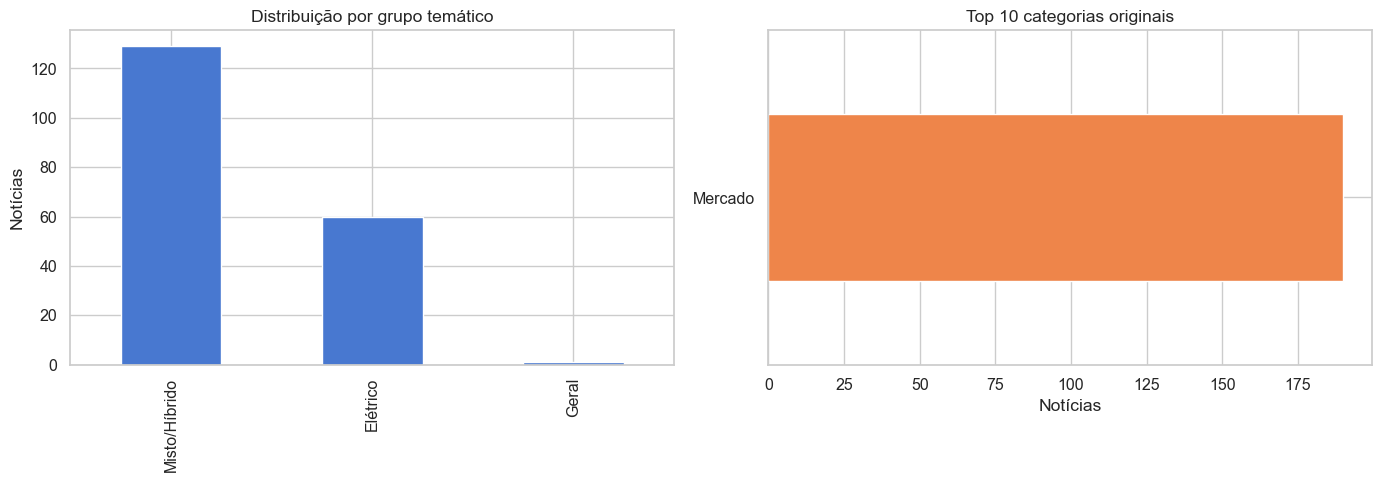

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df["grupo"].value_counts().plot(kind="bar", ax=axes[0], color=CORES[0])
axes[0].set_title("Distribuição por grupo temático")
axes[0].set_xlabel("")
axes[0].set_ylabel("Notícias")

top_categorias = df["categoria"].value_counts().head(10)
top_categorias.plot(kind="barh", ax=axes[1], color=CORES[1])
axes[1].invert_yaxis()
axes[1].set_title("Top 10 categorias originais")
axes[1].set_xlabel("Notícias")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

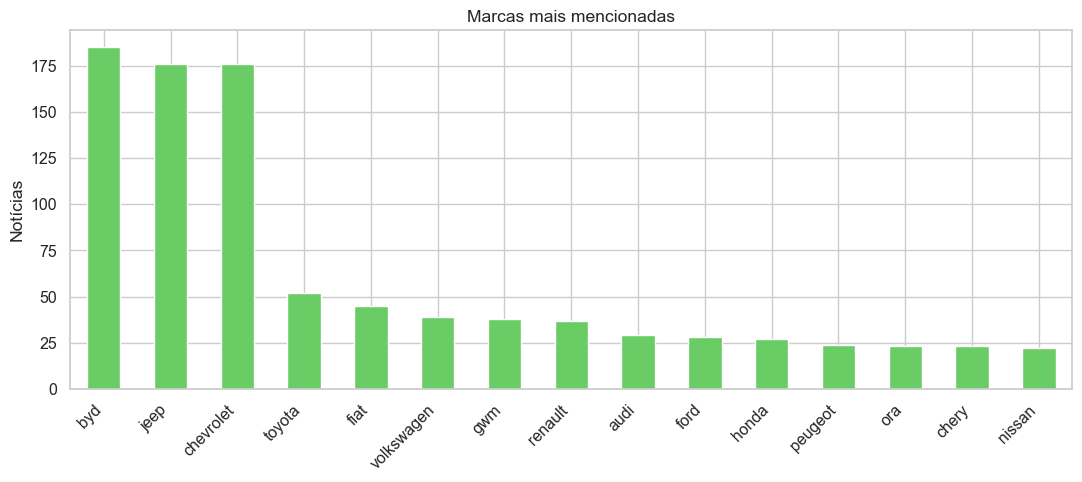

In [13]:
MARCAS = [
    "toyota", "volkswagen", "vw", "chevrolet", "gm", "fiat", "honda",
    "hyundai", "ford", "renault", "jeep", "nissan", "byd", "mercedes",
    "bmw", "audi", "tesla", "caoa", "chery", "citroen", "peugeot",
    "mitsubishi", "ram", "volvo", "kia", "gwm", "ora", "haval",
]

contagem_marcas = Counter()
for tokens in df["tokens"]:
    presentes = set(tokens) & set(MARCAS)
    contagem_marcas.update(presentes)

top_marcas = pd.Series(dict(contagem_marcas)).sort_values(ascending=False).head(15)

plt.figure(figsize=(11, 5))
top_marcas.plot(kind="bar", color=CORES[2])
plt.title("Marcas mais mencionadas")
plt.xlabel("")
plt.ylabel("Notícias")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 8. TF-IDF e termos distintivos

In [14]:
tfidf = TfidfVectorizer(max_features=1000, min_df=2, ngram_range=(1, 2))
X_tfidf = tfidf.fit_transform(df["texto_limpo"])
vocab = tfidf.get_feature_names_out()
df_tfidf = pd.DataFrame(X_tfidf.toarray(), columns=vocab)

print(f"Matriz TF-IDF: {df_tfidf.shape}")

Matriz TF-IDF: (190, 1000)


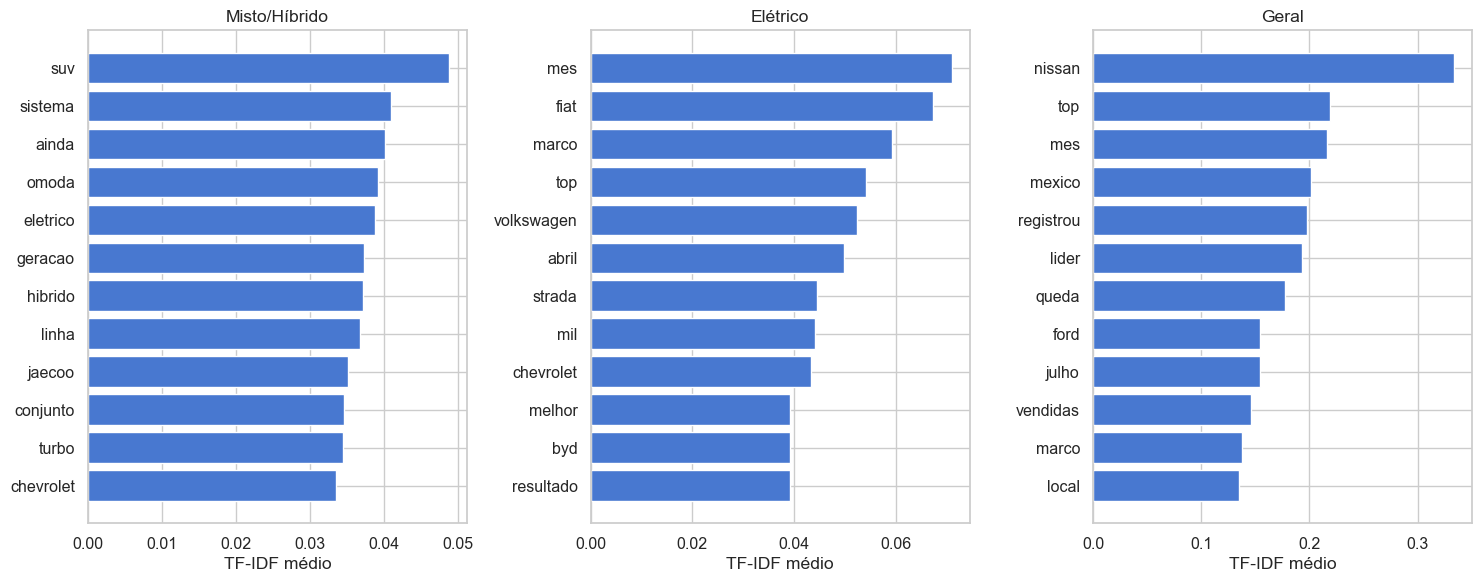

In [15]:
TOP_N = 12
grupos = df["grupo"].unique()

fig, axes = plt.subplots(1, len(grupos), figsize=(5 * len(grupos), 6), squeeze=False)

for ax, grupo in zip(axes.ravel(), grupos):
    media = df_tfidf[df["grupo"] == grupo].mean().sort_values(ascending=False).head(TOP_N)
    ax.barh(media.index[::-1], media.values[::-1], color=CORES[0])
    ax.set_title(grupo)
    ax.set_xlabel("TF-IDF médio")

plt.tight_layout()
plt.show()

In [16]:
try:
    from wordcloud import WordCloud

    fig, axes = plt.subplots(1, len(grupos), figsize=(6 * len(grupos), 4), squeeze=False)

    for ax, grupo in zip(axes.ravel(), grupos):
        texto_grupo = " ".join(df.loc[df["grupo"] == grupo, "texto_limpo"])
        if texto_grupo.strip():
            wc = WordCloud(width=800, height=400, background_color="white").generate(texto_grupo)
            ax.imshow(wc, interpolation="bilinear")
        ax.set_title(grupo)
        ax.axis("off")

    plt.tight_layout()
    plt.show()
except ModuleNotFoundError:
    print("Biblioteca wordcloud não instalada. Para usar esta célula, rode: %pip install wordcloud")

Biblioteca wordcloud não instalada. Para usar esta célula, rode: %pip install wordcloud


## 9. Visualização t-SNE

In [17]:
perplexity = min(30, max(2, len(df) - 1))
print(f"Rodando t-SNE com perplexity={perplexity}...")

tsne = TSNE(
    n_components=2,
    perplexity=perplexity,
    random_state=42,
    init="random",
    max_iter=1000,
)
embed = tsne.fit_transform(X_tfidf.toarray())

df_plot = pd.DataFrame({
    "x": embed[:, 0],
    "y": embed[:, 1],
    "grupo": df["grupo"].values,
    "titulo": df["titulo"].values,
    "categoria": df["categoria"].values,
    "data": df["ano_mes"].values,
})

fig = px.scatter(
    df_plot,
    x="x",
    y="y",
    color="grupo",
    hover_data={"titulo": True, "categoria": True, "data": True, "x": False, "y": False},
    title="t-SNE das notícias — TF-IDF por grupo temático",
    width=800,
    height=700,
    color_discrete_sequence=px.colors.qualitative.Set2,
)
fig.update_traces(marker=dict(size=6, opacity=0.75))
fig.write_html("tsne_motor1_clean.html")
fig.show()

print("Salvo: tsne_motor1_clean.html")

Rodando t-SNE com perplexity=30...


Salvo: tsne_motor1_clean.html
